# Project Setup 

In [2]:
# System & Data Libraries
import pandas as pd
import numpy as np
import duckdb

# Visualization
import matplotlib.pyplot as plt

# Econometrics & Time Series
from statsmodels.tsa.arima.model import ARIMA

# Plotting style setup
plt.style.use('seaborn-v0_8-whitegrid') # 



In [3]:
#OWID 
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df_raw = pd.read_csv(url)

print("Data Size:", df_raw.shape)
print(df_raw.head())

Data Size: (50411, 79)
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN             NaN              NaN  ...   
4                    NaN  NaN             NaN              NaN  ...   

   share_global_other_co2  share_of_temperature_change_from_ghg  \
0                     NaN                                   NaN   
1                     NaN                  

# Narrowing Down the Columns

In [4]:
selected_columns = ['country', 'year', 'co2', 'co2_per_capita']
df = df_raw[selected_columns].copy()

df.head()

,country,year,co2,co2_per_capita
0,Afghanistan,1750,NaN,NaN
1,Afghanistan,1751,NaN,NaN
2,Afghanistan,1752,NaN,NaN
3,Afghanistan,1753,NaN,NaN
4,Afghanistan,1754,NaN,NaN


# Filtering Countries, Years & Empty Values

In [5]:
target_countries = ['China', 'United States', 'Germany', 'India', 'Turkey']

df_filtered = df[
    (df['country'].isin(target_countries)) & 
    (df['year'] >= 1990)
].copy()

print("Filtered Data Size:", df_filtered.shape)
print("Countries in Data Set:", df_filtered['country'].unique())
df_filtered.head()

Filtered Data Size: (175, 4)
Countries in Data Set: <StringArray>
['China', 'Germany', 'India', 'Turkey', 'United States']
Length: 5, dtype: str


,country,year,co2,co2_per_capita
9899,China,1990,2483.534,2.153
9900,China,1991,2619.143,2.237
9901,China,1992,2731.290,2.306
9902,China,1993,2914.284,2.434
9903,China,1994,3093.891,2.559


In [6]:
# Checking Null values
print("Null Values:")
print(df_filtered.isnull().sum())

Null Values:
country           0
year              0
co2               0
co2_per_capita    0
dtype: int64


# Defining 2030 Goals

In [7]:
# 1. Define 2030 NDC targets in a dictionary (in Mt CO2)
ndc_targets_2030 = {
    'China': 11000.0,
    'United States': 3000.0,
    'Germany': 450.0,
    'India': 4000.0,
    'Turkey': 500.0
}

# 2. Map the 2030 targets into a new DataFrame column
df_filtered['ndc_target_2030'] = df_filtered['country'].map(ndc_targets_2030)

# 3. Verify the updated DataFrame structure
df_filtered.head()

,country,year,co2,co2_per_capita,ndc_target_2030
9899,China,1990,2483.534,2.153,11000.0
9900,China,1991,2619.143,2.237,11000.0
9901,China,1992,2731.290,2.306,11000.0
9902,China,1993,2914.284,2.434,11000.0
9903,China,1994,3093.891,2.559,11000.0


In [8]:
# Querying directly from the Pandas DataFrame using DuckDB
query = """
SELECT * 
FROM df_filtered 
LIMIT 5
"""

df_duckdb_test = duckdb.query(query).to_df()
df_duckdb_test

,country,year,co2,co2_per_capita,ndc_target_2030
0,China,1990,2483.534,2.153,11000.0
1,China,1991,2619.143,2.237,11000.0
2,China,1992,2731.290,2.306,11000.0
3,China,1993,2914.284,2.434,11000.0
4,China,1994,3093.891,2.559,11000.0


In [18]:
# YoY (Year-over-Year) Emission Change Calculation via DuckDB
query_yoy = """
SELECT 
    country,
    year,
    co2,
    ndc_target_2030,
    LAG(co2, 1) OVER (PARTITION BY country ORDER BY year) AS prev_year_co2,
    co2 - LAG(co2, 1) OVER (PARTITION BY country ORDER BY year) AS yoy_change
FROM df_filtered
ORDER BY country, year
"""

df_analytics = duckdb.sql(query_yoy).df()
df_analytics.head(6)

,country,year,co2,ndc_target_2030,prev_year_co2,yoy_change
0,China,1990,2483.534,11000.0,NaN,NaN
1,China,1991,2619.143,11000.0,2483.534,135.609
2,China,1992,2731.290,11000.0,2619.143,112.147
3,China,1993,2914.284,11000.0,2731.290,182.994
4,China,1994,3093.891,11000.0,2914.284,179.607
5,China,1995,3351.197,11000.0,3093.891,257.306


In [10]:
# Advanced Analytics Query: YoY Growth %, Target Deviation, and Status Labeling
query_analytics = """
WITH base_calculated AS (
    SELECT 
        country,
        year,
        co2,
        co2_per_capita,
        ndc_target_2030,
        LAG(co2, 1) OVER (PARTITION BY country ORDER BY year) AS prev_year_co2
    FROM df_filtered
)
SELECT 
    country,
    year,
    co2,
    ndc_target_2030,
    -- 1. Absolute deviation from 2030 NDC target (in Mt)
    ROUND(co2 - ndc_target_2030, 2) AS deviation_from_2030_target,
    
    -- 2. Percentage Year-over-Year Growth Rate (YoY Growth %)
    ROUND(((co2 - prev_year_co2) / prev_year_co2) * 100, 2) AS yoy_growth_pct,
    
    -- 3. Policy Status Categorization via Conditional Logic
    CASE 
        WHEN co2 > ndc_target_2030 THEN 'Above Target (Red)'
        ELSE 'Below Target (Green)'
    END AS status_vs_2030_target
FROM base_calculated
ORDER BY country, year
"""

# Execute query and assign directly to df_analytics
df_analytics = duckdb.sql(query_analytics).df()

# Inspect the most recent year's data (2023)
df_analytics[df_analytics['year'] == 2023]

,country,year,co2,ndc_target_2030,deviation_from_2030_target,yoy_growth_pct,status_vs_2030_target
33,China,2023,12172.009,11000.0,1172.01,3.93,Above Target (Red)
68,Germany,2023,593.766,450.0,143.77,-11.09,Above Target (Red)
103,India,2023,3062.756,4000.0,-937.24,8.18,Below Target (Green)
138,Turkey,2023,486.945,500.0,-13.06,9.77,Below Target (Green)
173,United States,2023,4918.407,3000.0,1918.41,-2.71,Above Target (Red)


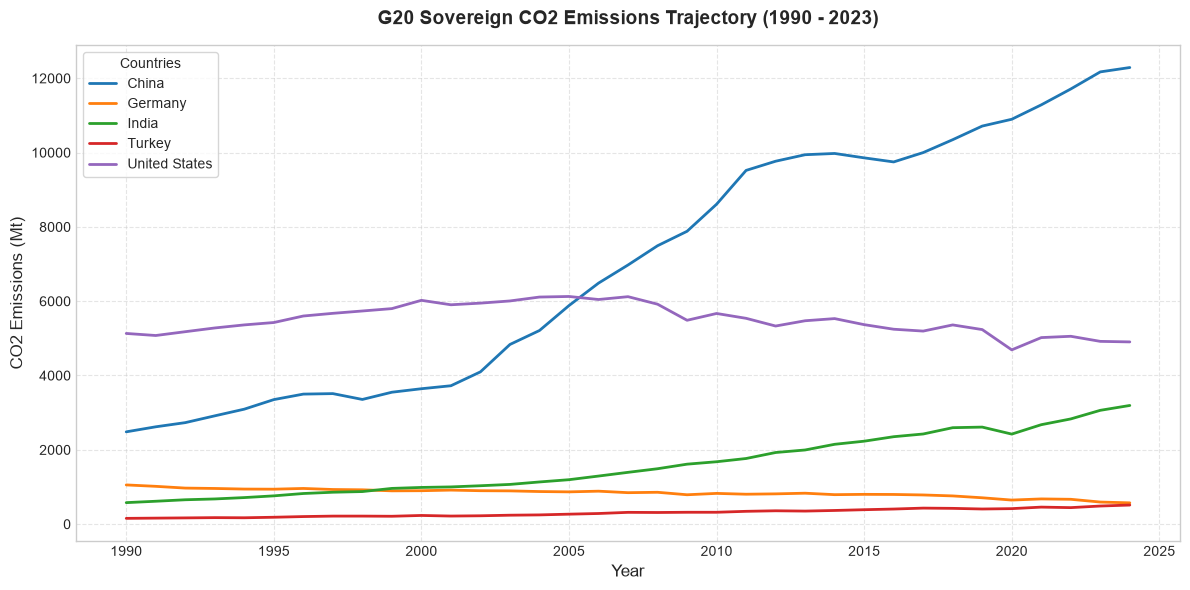

In [11]:
# Plotting historical CO2 emission trajectories for G20 countries (1990-2023)
plt.figure(figsize=(12, 6))

for country in df_analytics['country'].unique():
    country_data = df_analytics[df_analytics['country'] == country]
    plt.plot(country_data['year'], country_data['co2'], label=country, linewidth=2)

# Chart styling and labels
plt.title('G20 Sovereign CO2 Emissions Trajectory (1990 - 2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions (Mt)', fontsize=12)
plt.legend(title='Countries', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

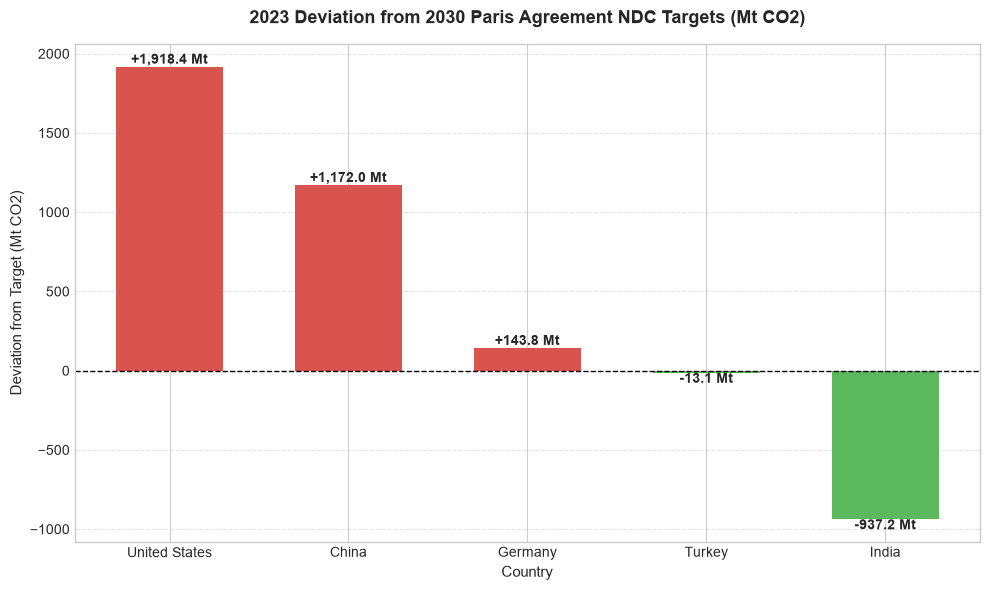

In [12]:
# Filter 2023 cross-sectional data and sort by target deviation
df_2023 = df_analytics[df_analytics['year'] == 2023].sort_values(by='deviation_from_2030_target', ascending=False)

# Color mapping: Red (#d9534f) for above target, Green (#5cb85c) for below target
colors = ['#d9534f' if val > 0 else '#5cb85c' for val in df_2023['deviation_from_2030_target']]

plt.figure(figsize=(10, 6))

# Plot bar chart
bars = plt.bar(df_2023['country'], df_2023['deviation_from_2030_target'], color=colors, width=0.6)

# Add reference line at zero (Target Baseline)
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Annotate numerical values on top/bottom of each bar
for bar in bars:
    yval = bar.get_height()
    va_align = 'bottom' if yval >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:+,.1f} Mt', 
             ha='center', va=va_align, fontsize=10, fontweight='bold')

# Chart formatting and labels
plt.title('2023 Deviation from 2030 Paris Agreement NDC Targets (Mt CO2)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=11)
plt.ylabel('Deviation from Target (Mt CO2)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Sadece Almanya verisini seçip 'year' sütununu indeks yapalım
df_germany = df_analytics[df_analytics['country'] == 'Germany'].set_index('year')['co2']

# Veri tipini zaman serisine uygun frekansta tanımlayalım (Annual / Yıllık)
df_germany.index = pd.date_range(start='1990', periods=len(df_germany), freq='YS')

In [14]:
# ARIMA(p=1, d=1, q=1) 
model = ARIMA(df_germany, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    co2   No. Observations:                   35
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -161.886
Date:                Sun, 06 Sep 2026   AIC                            329.772
Time:                        00:22:45   BIC                            334.351
Sample:                    01-01-1990   HQIC                           331.334
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    463.106      0.000       0.996       1.004
ma.L1         -0.9982      0.287     -3.476      0.001      -1.561      -0.435
sigma2       750.4563      0.000   1.93e+06      0.0

In [15]:
# Generate forecast for the next 6 years (2025-2030 period)
forecast_result = model_fit.get_forecast(steps=6)

# Extract predicted mean values
forecast_mean = forecast_result.predicted_mean

# Get the forecasted emission value for 2030
predicted_2030 = forecast_mean.iloc[-1]

# Display formatted results
print(f"Germany ARIMA 2030 Emission Forecast: {predicted_2030:.2f} Mt CO2")
print(f"Germany 2030 NDC Target: 450.00 Mt CO2")

Germany ARIMA 2030 Emission Forecast: 496.64 Mt CO2
Germany 2030 NDC Target: 450.00 Mt CO2


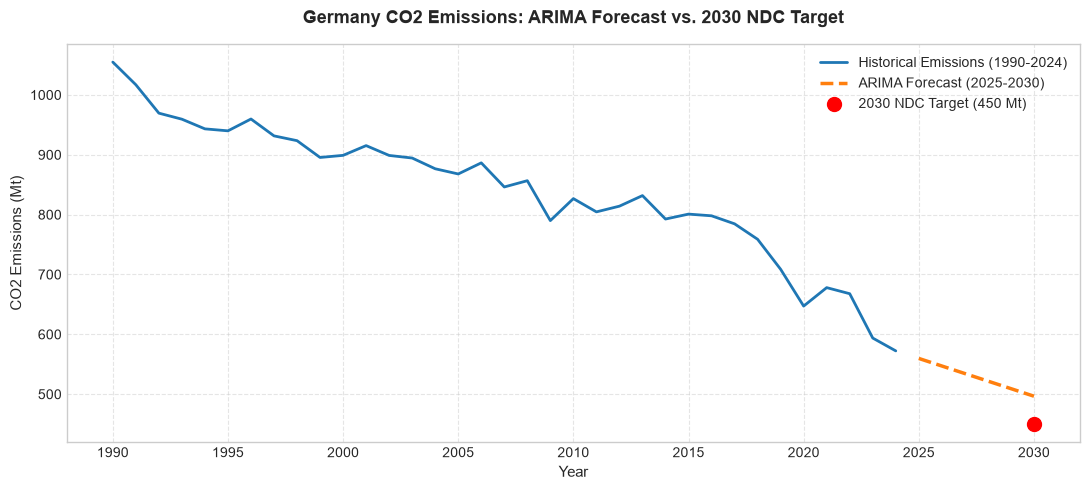

In [16]:
# Define future timeline for forecast (2025-2030)
future_years = [2025, 2026, 2027, 2028, 2029, 2030]

plt.figure(figsize=(11, 5))

# 1. Historical Emissions (1990 - 2024)
plt.plot(df_germany.index.year, df_germany.values, label='Historical Emissions (1990-2024)', color='#1f77b4', linewidth=2)

# 2. Econometric ARIMA Forecast (2025 - 2030)
plt.plot(future_years, forecast_mean.values, label='ARIMA Forecast (2025-2030)', color='#ff7f0e', linestyle='--', linewidth=2.5)

# 3. 2030 NDC Target Point (450 Mt)
plt.scatter(2030, 450.0, color='red', s=100, zorder=5, label='2030 NDC Target (450 Mt)')

# Title and Labeling
plt.title('Germany CO2 Emissions: ARIMA Forecast vs. 2030 NDC Target', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11)
plt.ylabel('CO2 Emissions (Mt)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()